# Bank Loan Default Risk Analysis

## Business Problem Statement

Banks face significant financial losses due to loan defaults. Identifying risky borrowers before loan approval is essential to minimize credit risk and improve profitability.

## Objective

- Analyze historical loan application data.
- Identify factors affecting loan approvals.
- Discover high-risk borrower segments.
- Provide recommendations to reduce default risk.

## Tech Stack

- Python (Pandas, NumPy, Matplotlib, Seaborn)
- SQL (MySQL)
- Power BI
- Git & GitHub

In [77]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Set plotting style
sns.set_style('whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


In [78]:
# Load Dataset

df = pd.read_csv('../data/raw/loan_data.csv')

# Display first 5 rows
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [79]:
# Check dataset dimensions

print("Shape of Dataset:", df.shape)


Shape of Dataset: (614, 13)


In [80]:
# Display column names

df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [81]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [82]:
# Check missing values

df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [83]:
# Missing Values Percentage

missing_values = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': round((df.isnull().sum()/len(df))*100, 2)
})

missing_values

,Missing Values,Percentage (%)
Loan_ID,0,0.00
Gender,13,2.12
Married,3,0.49
Dependents,15,2.44
Education,0,0.00
Self_Employed,32,5.21
ApplicantIncome,0,0.00
CoapplicantIncome,0,0.00
LoanAmount,22,3.58
Loan_Amount_Term,14,2.28


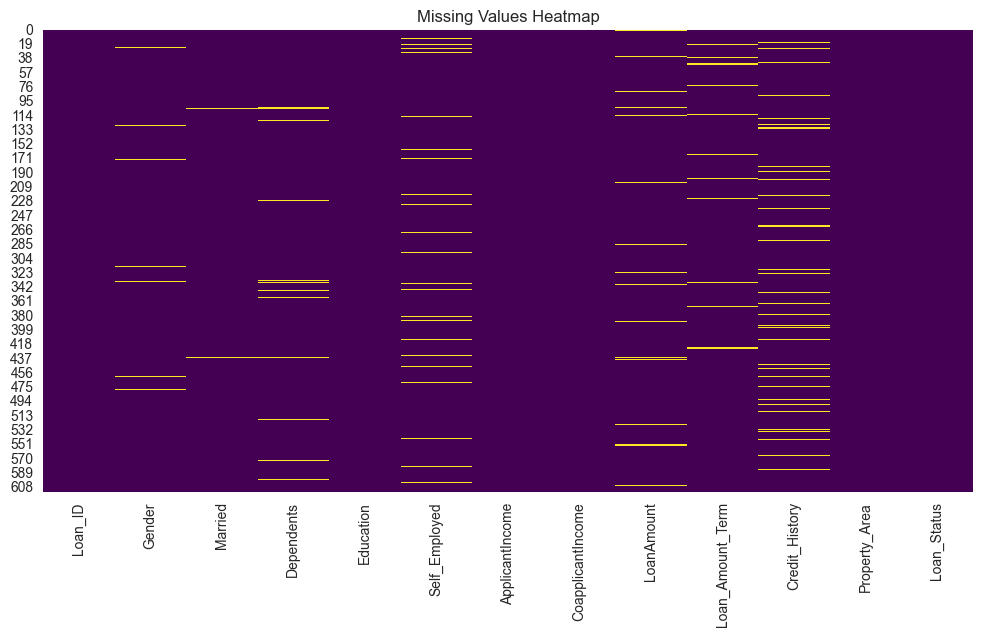

In [84]:
# Visualize Missing Values

plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap='viridis')

plt.title('Missing Values Heatmap')
plt.show()

In [85]:
# Filling missing values

# Categorical columns -> Mode

df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)

df['Married'].fillna(df['Married'].mode()[0], inplace=True)

df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)

df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

# Numerical columns -> Median

df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)

# Credit History -> Mode

df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

print("Missing values handled successfully!")

Missing values handled successfully!


C:\Users\Mahathi Vaka\AppData\Local\Temp\ipykernel_15432\691667751.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
C:\Users\Mahathi Vaka\AppData\Local\Temp\ipykernel_15432\691667751.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series throu

In [86]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [87]:
# Fill missing values

df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

df['Married'] = df['Married'].fillna(df['Married'].mode()[0])

df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])

df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(
    df['Loan_Amount_Term'].median()
)

df['Credit_History'] = df['Credit_History'].fillna(
    df['Credit_History'].mode()[0]
)

print("Missing values handled successfully!")

Missing values handled successfully!


In [88]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [89]:
# Check duplicate records

print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


In [90]:
# Create Total Income column

df['Total_Income'] = (
    df['ApplicantIncome'] +
    df['CoapplicantIncome']
)

df[['ApplicantIncome',
    'CoapplicantIncome',
    'Total_Income']].head()

,ApplicantIncome,CoapplicantIncome,Total_Income
0,5849,0.0,5849.0
1,4583,1508.0,6091.0
2,3000,0.0,3000.0
3,2583,2358.0,4941.0
4,6000,0.0,6000.0


In [91]:
# Create EMI Feature

df['EMI'] = (
    df['LoanAmount'] /
    df['Loan_Amount_Term']
)

df[['LoanAmount',
    'Loan_Amount_Term',
    'EMI']].head()

,LoanAmount,Loan_Amount_Term,EMI
0,128.0,360.0,0.355556
1,128.0,360.0,0.355556
2,66.0,360.0,0.183333
3,120.0,360.0,0.333333
4,141.0,360.0,0.391667


In [92]:
# Create Debt-to-Income Ratio

df['DTI_Ratio'] = (
    df['LoanAmount'] /
    df['Total_Income']
)

df[['LoanAmount',
    'Total_Income',
    'DTI_Ratio']].head()

,LoanAmount,Total_Income,DTI_Ratio
0,128.0,5849.0,0.021884
1,128.0,6091.0,0.021015
2,66.0,3000.0,0.022000
3,120.0,4941.0,0.024287
4,141.0,6000.0,0.023500


# Exploratory Data Analysis (EDA)

## EDA 1: Loan Approval Distribution

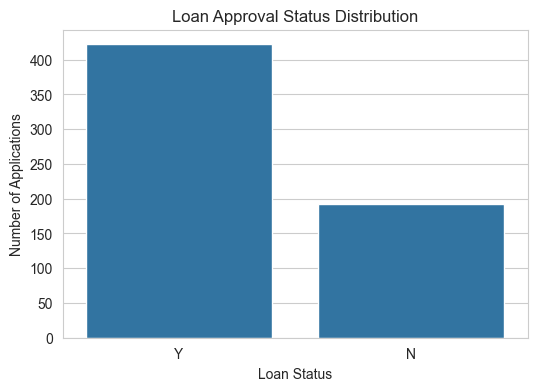

In [93]:
# Loan Approval Distribution

plt.figure(figsize=(6,4))

sns.countplot(x='Loan_Status', data=df)

plt.title('Loan Approval Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Number of Applications')

plt.show()

### Business Question

What proportion of loan applications are approved versus rejected?

### Insight

Approximately 69% of loan applications were approved, while around 31% were rejected. This indicates that the bank approves the majority of applications.

### Business Implication

The bank approves most loan applications. Further analysis is required to identify the factors influencing loan approvals and to ensure that high-risk applicants are not being approved.

## EDA 2: Gender vs Loan Approval

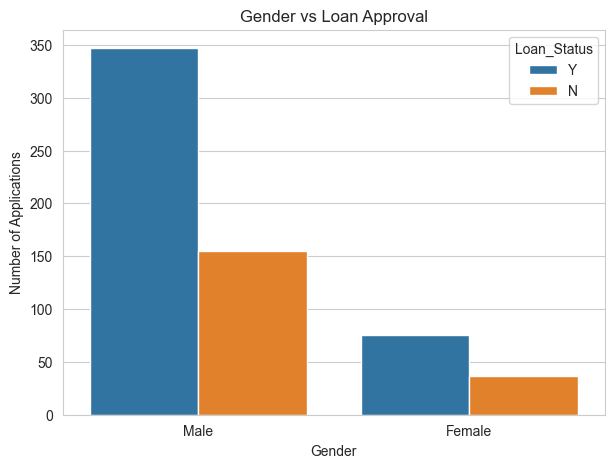

In [94]:
# Gender vs Loan Approval

plt.figure(figsize=(7,5))

sns.countplot(x='Gender',
              hue='Loan_Status',
              data=df)

plt.title('Gender vs Loan Approval')
plt.xlabel('Gender')
plt.ylabel('Number of Applications')

plt.show()

### Business Question

Does gender influence loan approval decisions?

### Insight

Male applicants account for a larger share of both loan applications and approvals compared to female applicants.

### Business Implication

Since male applicants represent the majority of loan applications, the bank should further investigate whether approval decisions are based solely on application volume or if any unintended bias exists in the approval process.

## EDA 3: Education vs Loan Approval

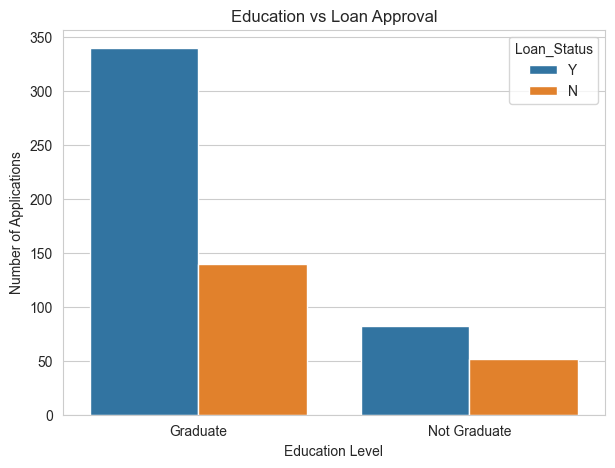

In [95]:
# Education vs Loan Approval

plt.figure(figsize=(7,5))

sns.countplot(x='Education',
              hue='Loan_Status',
              data=df)

plt.title('Education vs Loan Approval')
plt.xlabel('Education Level')
plt.ylabel('Number of Applications')

plt.show()

### Business Question

Does the education level of applicants influence loan approval decisions?

### Insight

Graduate applicants account for a higher number of loan approvals compared to non-graduate applicants.

### Business Implication

Educational qualification may influence loan approval decisions, as graduates are often perceived to have more stable income sources and lower credit risk.

## EDA 4: Property Area vs Loan Approval

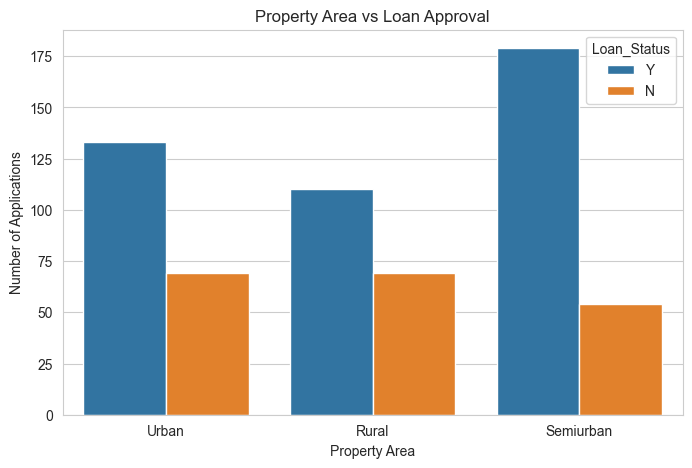

In [96]:
# Property Area vs Loan Approval

plt.figure(figsize=(8,5))

sns.countplot(x='Property_Area',
              hue='Loan_Status',
              data=df)

plt.title('Property Area vs Loan Approval')
plt.xlabel('Property Area')
plt.ylabel('Number of Applications')

plt.show()

### Business Question

Does the applicant's property area influence loan approval?

### Insight

Applicants from semi-urban areas received the highest number of loan approvals.

### Business Implication

The bank appears to have a stronger lending presence in semi-urban regions, indicating potential growth opportunities and lower perceived risk in these markets.

## EDA 5: Credit History vs Loan Approval

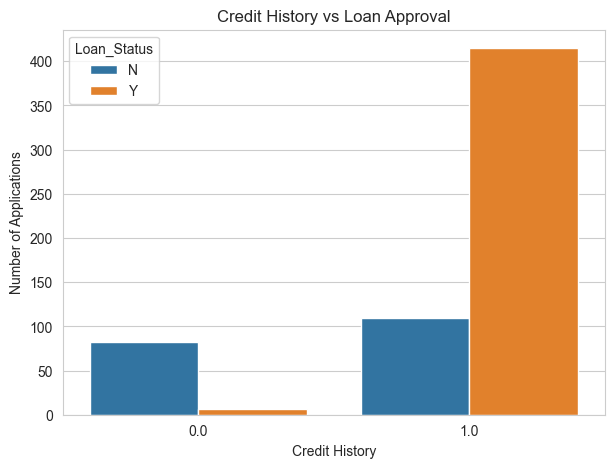

In [97]:
# Credit History vs Loan Approval

plt.figure(figsize=(7,5))

sns.countplot(x='Credit_History',
              hue='Loan_Status',
              data=df)

plt.title('Credit History vs Loan Approval')
plt.xlabel('Credit History')
plt.ylabel('Number of Applications')

plt.show()

### Business Question

How does an applicant's credit history affect loan approval decisions?

### Insight

Applicants with a positive credit history (1.0) received significantly more loan approvals compared to applicants with poor or missing credit history.

### Business Implication

Credit history is one of the strongest predictors of loan approval. Banks should continue prioritizing applicants with good repayment records to minimize default risk.

## EDA 6: Total Income Distribution

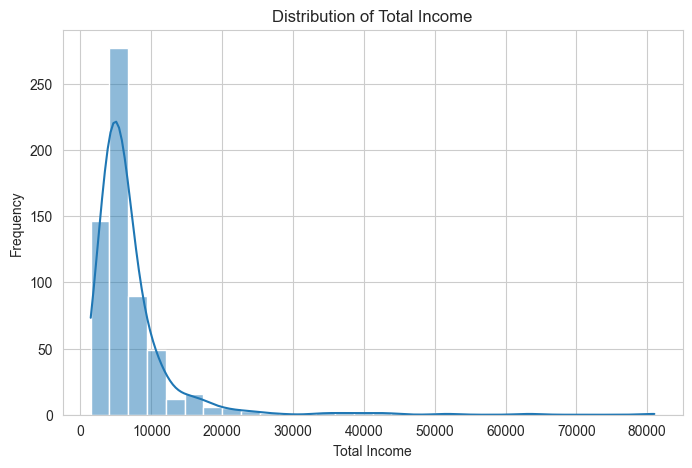

In [98]:
# Total Income Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['Total_Income'],
             bins=30,
             kde=True)

plt.title('Distribution of Total Income')
plt.xlabel('Total Income')
plt.ylabel('Frequency')

plt.show()

### Business Question

What is the distribution of applicants' total income?

### Insight

Most applicants fall within lower-to-middle income ranges, while a few applicants have exceptionally high incomes.

### Business Implication

The presence of high-income outliers indicates that the bank serves a diverse customer base. Different loan products may be designed for various income segments.

## EDA 7: Loan Amount Distribution

### Business Objective

Analyze the distribution of loan amounts requested by applicants to understand lending patterns and identify potential outliers.

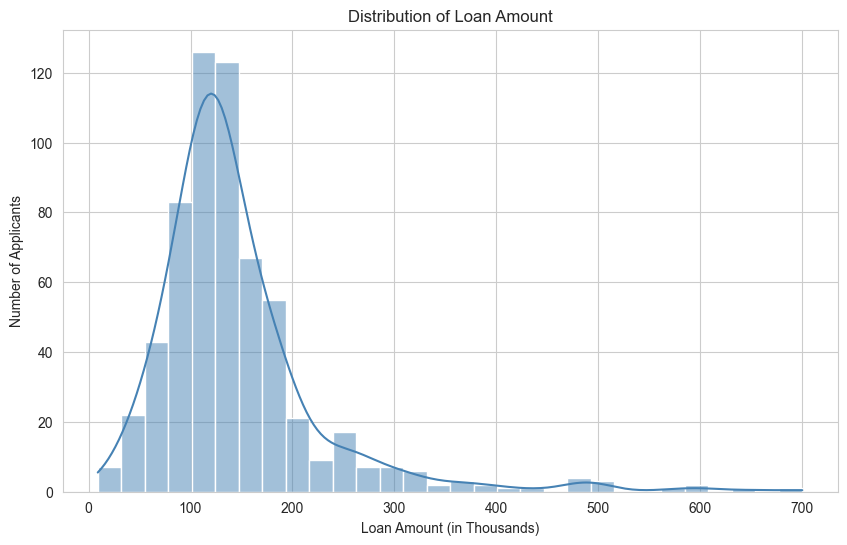

In [99]:
# Loan Amount Distribution

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='LoanAmount',
    bins=30,
    kde=True,
    color='steelblue'
)

plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount (in Thousands)")
plt.ylabel("Number of Applicants")

plt.show()

### Business Question

How are loan amounts distributed among applicants?

### Insight

- Most applicants request low-to-medium loan amounts.
- Only a small number of applicants request very large loans.
- The distribution is positively skewed, indicating the presence of a few high-value loan applications.

### Banking Interpretation

Retail loans dominate the bank's loan portfolio. High-value loans represent a smaller portion of applications but carry greater financial exposure.

### Recommendation

The bank should apply enhanced credit assessment and risk monitoring for high-value loan applications while maintaining efficient approval processes for lower-risk retail loans.

## EDA 8: Applicant Income vs Loan Amount

### Business Objective

Analyze the relationship between applicant income and requested loan amount to understand whether income influences borrowing behavior.


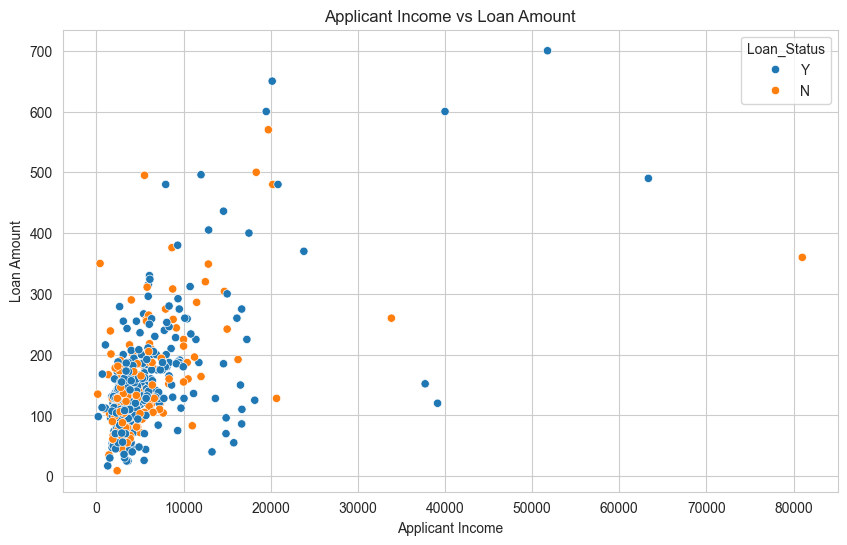

In [100]:
# Applicant Income vs Loan Amount

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='ApplicantIncome',
    y='LoanAmount',
    hue='Loan_Status'
)

plt.title("Applicant Income vs Loan Amount")
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")

plt.show()

### Business Question

Does applicant income influence the requested loan amount?

### Insight

- Applicants with higher incomes generally request larger loan amounts.
- However, applicants with similar incomes may request different loan amounts.
- Loan approval is influenced by additional factors beyond income.

### Banking Interpretation

Income is an important indicator of repayment capacity, but it should be evaluated alongside credit history, employment status, and debt obligations to assess overall credit risk.

### Recommendation

The bank should combine applicant income with other financial indicators rather than relying solely on income when making lending decisions.

## EDA 9: Marital Status vs Loan Approval

### Business Objective

Analyze whether marital status has an impact on loan approval decisions.

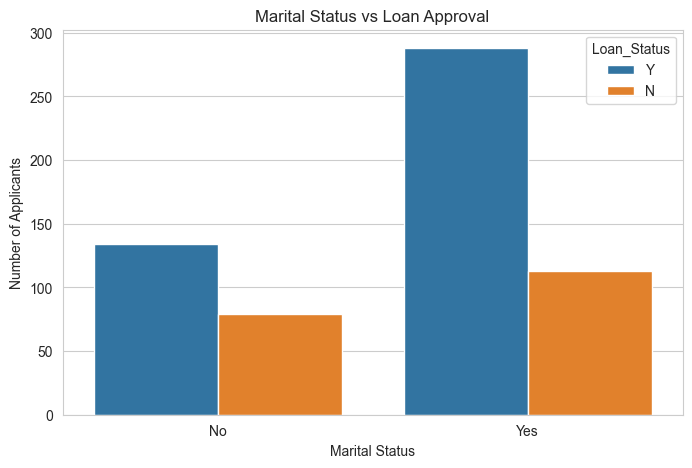

In [101]:
# Marital Status vs Loan Approval

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Married',
    hue='Loan_Status'
)

plt.title("Marital Status vs Loan Approval")
plt.xlabel("Marital Status")
plt.ylabel("Number of Applicants")

plt.show()

### Business Question

Does marital status influence loan approval decisions?

### Insight

- Married applicants received more loan approvals than unmarried applicants.
- Married applicants also represent a larger share of total loan applications.

### Banking Interpretation

Married applicants may demonstrate greater financial stability or dual-income support, which can positively influence lending decisions.

### Recommendation

Marital status should not be used in isolation. It should be evaluated together with income, credit history, and repayment capacity to ensure fair and balanced lending decisions.

## EDA 10: Dependents vs Loan Approval

### Business Objective

Analyze whether the number of dependents affects loan approval decisions.

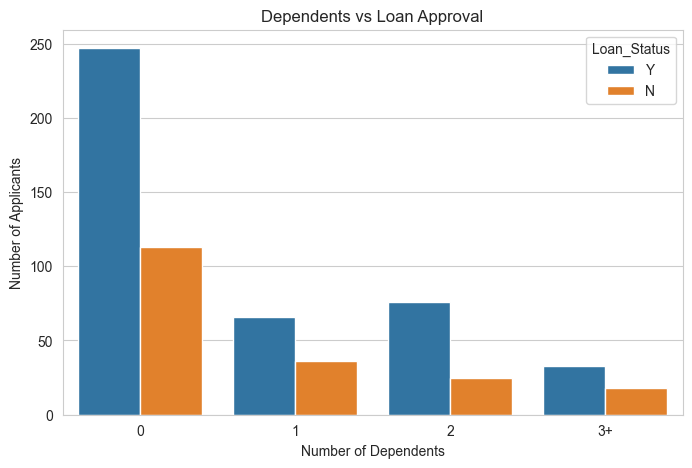

In [102]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Dependents',
    hue='Loan_Status'
)

plt.title("Dependents vs Loan Approval")
plt.xlabel("Number of Dependents")
plt.ylabel("Number of Applicants")

plt.show()

### Business Question

Does the number of dependents influence loan approval?

### Insight

Applicants with fewer dependents received the highest number of loan approvals, while applicants with three or more dependents had comparatively fewer approvals.

### Banking Interpretation

Applicants with fewer financial dependents may have greater repayment capacity, making them relatively lower-risk borrowers.

### Recommendation

The bank should consider the number of dependents as one of several factors in assessing repayment ability, rather than using it as a standalone approval criterion.

## EDA 11: Self-Employed vs Loan Approval

### Business Objective

Analyze how self-employment status affects loan approval decisions.

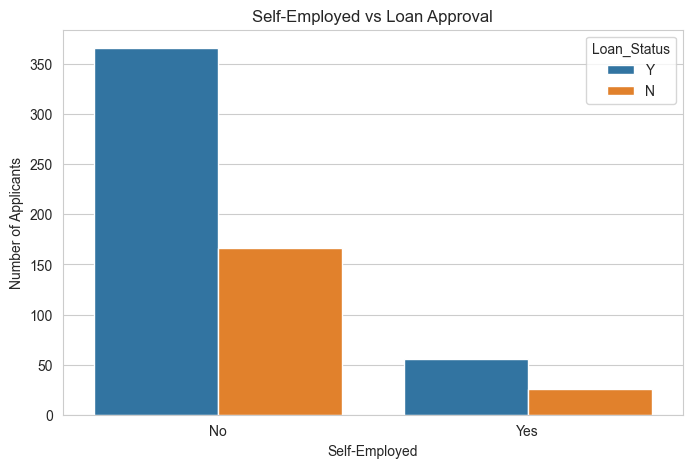

In [103]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Self_Employed',
    hue='Loan_Status'
)

plt.title("Self-Employed vs Loan Approval")
plt.xlabel("Self-Employed")
plt.ylabel("Number of Applicants")

plt.show()

### Business Question

Does self-employment influence loan approval?

### Insight

Both salaried and self-employed applicants receive loan approvals, although salaried applicants represent a larger proportion of approvals.

### Banking Interpretation

Stable employment often provides more predictable income, reducing perceived lending risk.

### Recommendation

The bank should evaluate business income consistency and financial documentation for self-employed applicants rather than relying solely on employment type.

## EDA 12: Education vs Loan Amount

### Business Objective

Compare requested loan amounts across different education levels.

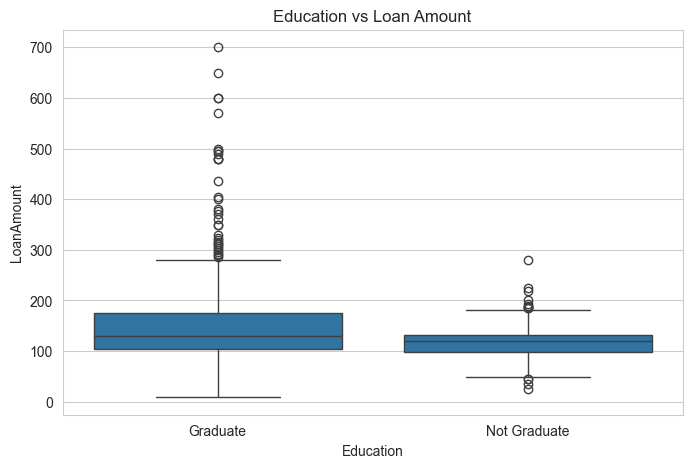

In [104]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Education',
    y='LoanAmount'
)

plt.title("Education vs Loan Amount")

plt.show()

### Business Question

Do graduates request different loan amounts than non-graduates?

### Insight

Graduates generally request slightly higher loan amounts, although both groups exhibit considerable variation.

### Banking Interpretation

Educational qualifications may influence earning potential and borrowing capacity.

### Recommendation

Education should complement financial metrics such as income and credit history during credit evaluation.

## EDA 13: Correlation Analysis

### Business Objective

Identify relationships among numerical variables affecting loan decisions.

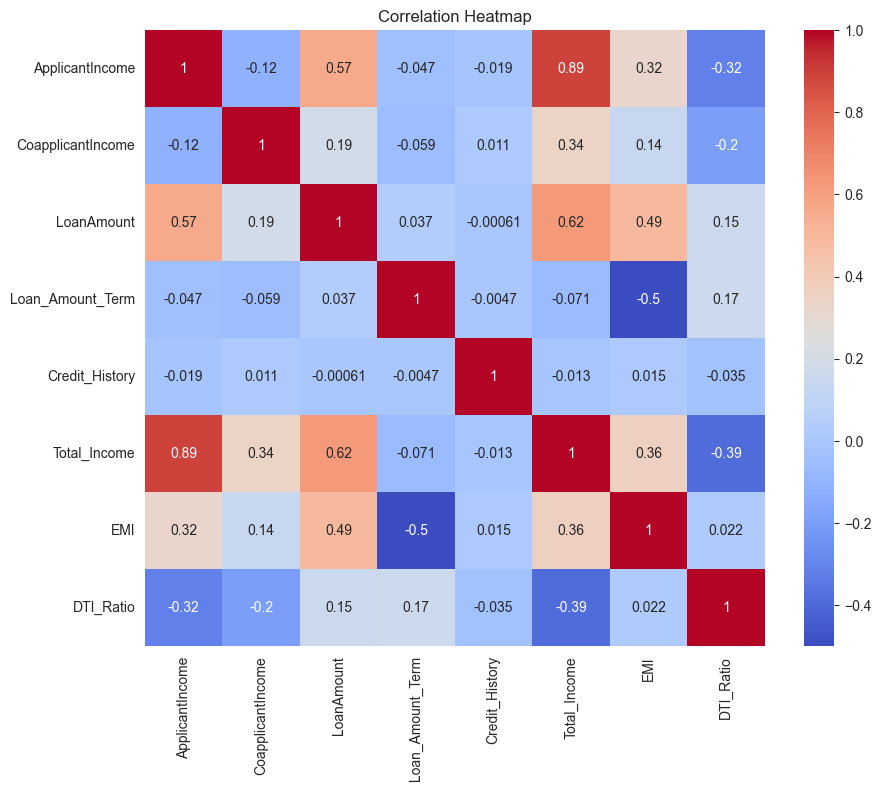

In [105]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

### Business Question

Which numerical variables are strongly related?

### Insight

Total Income shows a positive relationship with Applicant Income, while EMI and Loan Amount also exhibit correlation.

### Banking Interpretation

Understanding these relationships helps identify key variables influencing lending decisions and supports future predictive modeling.

### Recommendation

Focus on variables with stronger relationships when developing credit risk models.

## EDA 14: Debt-to-Income Ratio Distribution

### Business Objective

Analyze the distribution of the Debt-to-Income (DTI) ratio across applicants.

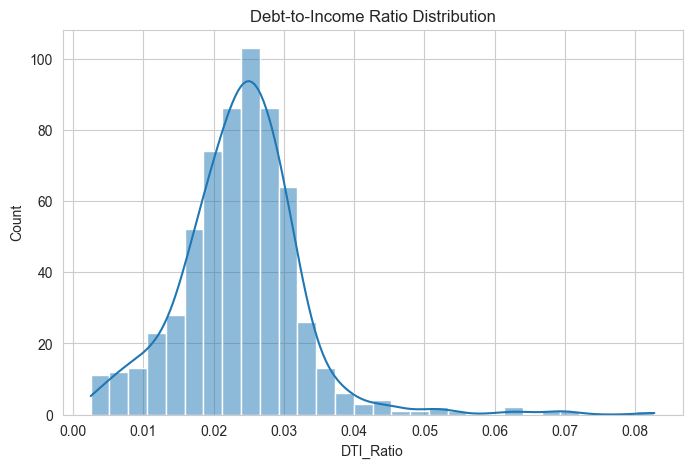

In [106]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['DTI_Ratio'],
    bins=30,
    kde=True
)

plt.title("Debt-to-Income Ratio Distribution")

plt.show()

### Business Question

How is the Debt-to-Income Ratio distributed among applicants?

### Insight

Most applicants have relatively low DTI ratios, while a small number exhibit significantly higher debt burdens.

### Banking Interpretation

Applicants with higher DTI ratios may face greater repayment challenges, increasing default risk.

### Recommendation

Introduce DTI thresholds as part of the bank's credit assessment framework.

## EDA 15: Total Income by Loan Status

### Business Objective

Compare total household income between approved and rejected loan applications.

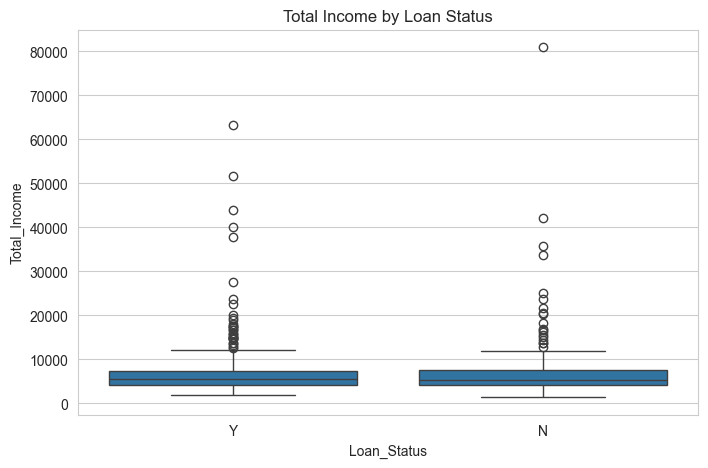

In [107]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Loan_Status',
    y='Total_Income'
)

plt.title("Total Income by Loan Status")

plt.show()

### Business Question

Do approved applicants have higher household incomes than rejected applicants?

### Insight

Approved applicants generally exhibit higher total household incomes compared to rejected applicants.

### Banking Interpretation

Higher household income improves repayment capacity and contributes positively to lending decisions.

### Recommendation

Household income should remain an important component of credit assessment, while balancing it with credit history and debt obligations.

In [108]:
# Export cleaned dataset

df.to_csv(
    '../data/cleaned/loan_data_cleaned.csv',
    index=False
)

print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!
